# Story-2

`Suppose 9-1-1 Emergency handling organization has gathered a lot of data. Now they have hired Data Analytics firm to analyze the dataset and tell them what all they can do with this dataset. Possible set of analysis we can do on this kind of dataset are:-`

`- About most hot category of Stress calls`

`- Which area to focus based on calls analysis`

For this capstone project we will be analyzing some 911 call data. The data contains the following fields:

* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)

Just go along with this notebook and try to complete the instructions or answer the questions in bold using your Python and Data Science skills!

## Data and Setup

____
** Import numpy and pandas **

In [ ]:
import numpy as np
import pandas as pd

** Import visualization libraries and set %matplotlib inline. **

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

** Read in the csv file as a dataframe called df **

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [ ]:
df = pd.read_csv('../data/911.csv')

** Check the info() of the df **

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456573 entries, 0 to 456572
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        456573 non-null  float64
 1   lng        456573 non-null  float64
 2   desc       456573 non-null  object 
 3   zip        400504 non-null  float64
 4   title      456573 non-null  object 
 5   timeStamp  456573 non-null  object 
 6   twp        456399 non-null  object 
 7   addr       456573 non-null  object 
 8   e          456572 non-null  float64
dtypes: float64(4), object(5)
memory usage: 31.4+ MB


** Check the head of df **

In [ ]:
df.head(10)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1.0
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1.0
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1.0
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1.0
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1.0
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 15:39:04,LANSDALE,CANNON AVE & W 9TH ST,1.0
6,40.182111,-75.127795,LAUREL AVE & OAKDALE AVE; HORSHAM; Station 35...,19044.0,EMS: NAUSEA/VOMITING,2015-12-10 16:46:48,HORSHAM,LAUREL AVE & OAKDALE AVE,1.0
7,40.217286,-75.405182,COLLEGEVILLE RD & LYWISKI RD; SKIPPACK; Stati...,19426.0,EMS: RESPIRATORY EMERGENCY,2015-12-10 16:17:05,SKIPPACK,COLLEGEVILLE RD & LYWISKI RD,1.0
8,40.289027,-75.399590,MAIN ST & OLD SUMNEYTOWN PIKE; LOWER SALFORD;...,19438.0,EMS: SYNCOPAL EPISODE,2015-12-10 16:51:42,LOWER SALFORD,MAIN ST & OLD SUMNEYTOWN PIKE,1.0
9,40.102398,-75.291458,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD; PLYM...,19462.0,Traffic: VEHICLE ACCIDENT -,2015-12-10 17:35:41,PLYMOUTH,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD,1.0


## Basic Questions

** What are the top 5 zipcodes groupby townships for 911 calls? **

In [ ]:
df_zip = pd.DataFrame(df['zip'].value_counts().groupby(df['twp']).nlargest(5))
#df_zip.rename(columns = {'zip': 'Top 5'},inplace = True)
df_zip.style.background_gradient(cmap='Blues')

** What are the top 5 townships (twp) for 911 calls? **

In [ ]:
df_twp = pd.DataFrame(df['twp'].value_counts().head(5))
df_twp.rename(columns = {'twp':'Top 5'},inplace = True)
df_twp.style.background_gradient(cmap='Greens')

,Top 5
LOWER MERION,39176
ABINGTON,27712
NORRISTOWN,25551
UPPER MERION,24641
CHELTENHAM,20977


** Take a look at the 'title' column, how many unique title codes are there? **

In [ ]:
df['title'].nunique()

141

## Creating new features

** In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.** 

**For example, if the title column value is EMS: BACK PAINS/INJURY , the Reason column value would be EMS. **

In [ ]:
df['Reason'] = df['title'].apply(lambda title: title.split(':')[0])

In [ ]:
df['title_code'] = df['title'].apply(lambda title: title.split(':')[1])

In [ ]:
df["Station"] = df["desc"].str.extract("(Station.+?);", expand=False).str.strip()

In [ ]:
df["timeStamp"] = pd.to_datetime(df["timeStamp"])

In [ ]:
df["Day of week"] = df["timeStamp"].apply(lambda time: time.dayofweek)
df["Date"] = df["timeStamp"].apply(lambda time: time.day)
df["Month"] = df["timeStamp"].apply(lambda time: time.month)
df["Year"] = df["timeStamp"].apply(lambda time: time.year)
df["Hour"] = df["timeStamp"].apply(lambda time: time.hour)

In [ ]:
dtmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df["Day of week"] = df["Day of week"].map(dtmap)

In [ ]:
df["Day/Night"] = df["timeStamp"].apply(lambda x : "Night" if int(x.strftime("%H")) > 18 else "Day")

** What is the most common Reason for a 911 call based off of this new column? **

In [ ]:
df['Reason'].value_counts()

EMS        332692
Traffic    230208
Fire       100622
Name: Reason, dtype: int64

** Now use seaborn to create a countplot of 911 calls by Reason. **

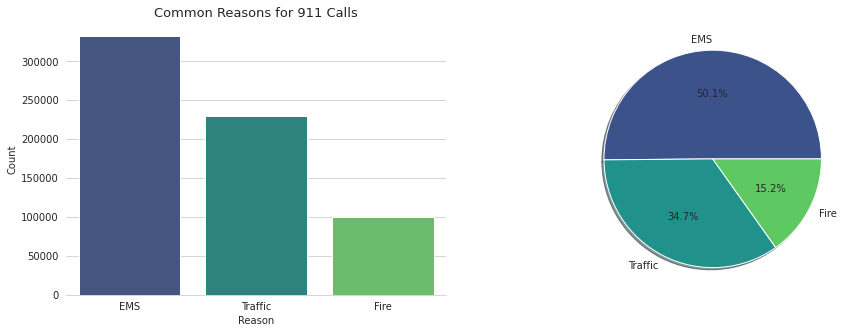

In [ ]:
# In seaborn we can dircty select the palettes instead of making the color combinations by our self
# These palettes gives the better visualization to us

fig, axes = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='Reason',data=df,order=df['Reason'].value_counts().index,ax=axes[0],palette='viridis')
axes[0].set_title('Common Reasons for 911 Calls',size=13)
axes[0].set(xlabel='Reason',ylabel='Count')
df['Reason'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[1],shadow=True,colors=['#3b528b','#21918c','#5ec962'])
axes[1].set(xlabel='',ylabel='')
sns.despine(bottom=False, left=True)

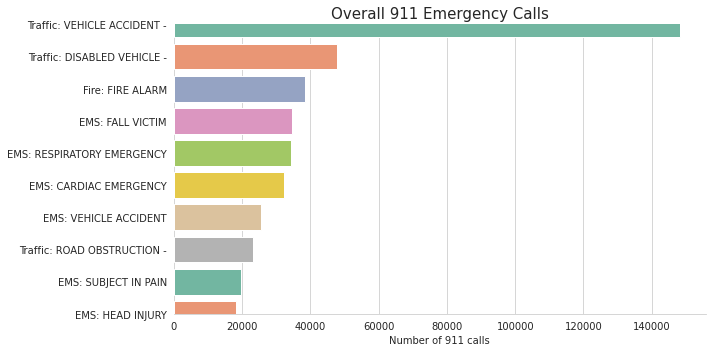

In [ ]:
fig,axes = plt.subplots(figsize=(10,5))
sns.countplot(y='title',data=df,order=df['title'].value_counts().index,palette='Set2')
sns.despine(bottom=False,left=True)
axes.set_ylim([9,0])
axes.set_title('Overall 911 Emergency Calls',size=15)
axes.set(xlabel='Number of 911 calls',ylabel='')
plt.tight_layout()

#### Top 10 Stations were incidents were reported

In [ ]:
df["Station"].value_counts().head(10)

Station 308A    17052
Station 329     15222
Station 313     14039
Station 381     10940
Station 317     10844
Station 345      9899
Station 308      9269
Station 351      8499
Station 345B     8223
Station 382      7573
Name: Station, dtype: int64

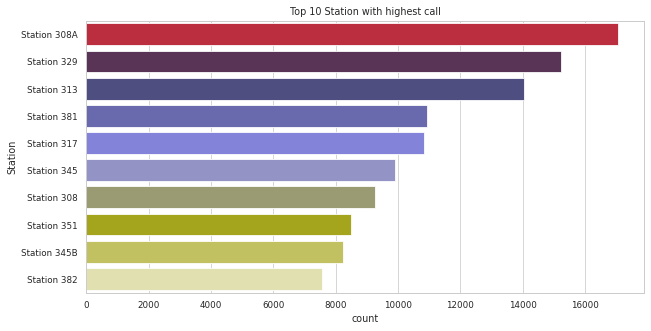

In [ ]:
plt.figure(figsize=(10,5))
sns.set_context("paper", font_scale =1)
sns.countplot(y='Station',data=df, palette = "gist_stern", order = df["Station"].value_counts().index[:10])
plt.title("Top 10 Station with highest call")
sns.set_style("whitegrid")

#### Finding out if the calls made more in day or night time

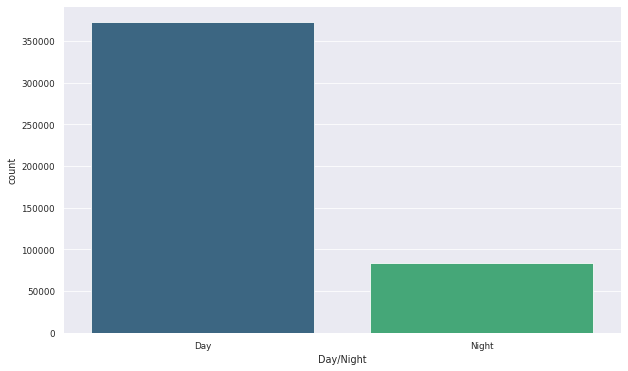

In [ ]:
plt.figure(figsize=(10,6))
sns.set_context("paper", font_scale =1)
sns.countplot(x='Day/Night',data=df,palette='viridis')
sns.set_style("darkgrid")

Let's explore the various types of calls we get related Traffic

---



Text(0.5, 1.0, 'Traffic 911 Emergency Calls')

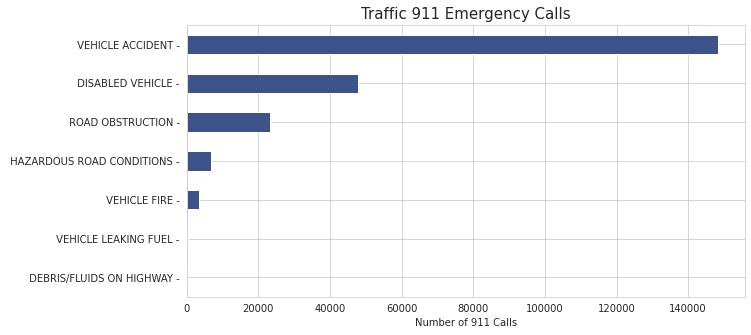

In [ ]:
df[df['Reason']=='Traffic'].groupby('title_code').count()['lat'].sort_values(ascending=True).plot(kind='barh',figsize=(10,5),color='#3b528b')
plt.xlabel('Number of 911 Calls')
plt.ylabel('')
plt.title('Traffic 911 Emergency Calls', fontsize=15)

Let's explore the various types of calls we get related Fire

Text(0.5, 1.0, 'Fire 911 Emergency Calls')

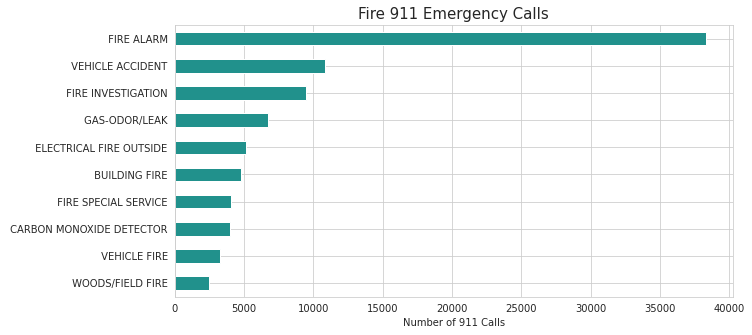

In [ ]:
df[df['Reason']=='Fire'].groupby('title_code').count()['lat'].sort_values(ascending=True).tail(10).plot(kind='barh',figsize=(10,5),color='#21918c')
plt.xlabel('Number of 911 Calls')
plt.ylabel('')
plt.title('Fire 911 Emergency Calls', fontsize=15)



Let's explore the various types of calls we get related EMS

Text(0.5, 1.0, 'EMS 911 Emergency Calls')

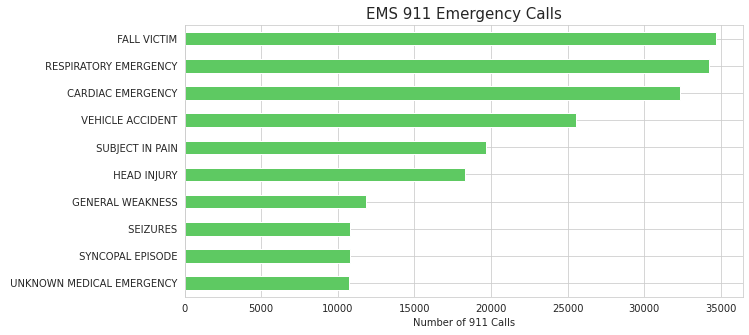

In [ ]:
df[df['Reason']=='EMS'].groupby('title_code').count()['lat'].sort_values(ascending=True).tail(10).plot(kind='barh', figsize=(10, 5), color='#5ec962')
plt.xlabel('Number of 911 Calls')
plt.ylabel('')
plt.title('EMS 911 Emergency Calls', fontsize=15)

___
** Now let us begin to focus on time information. What is the data type of the objects in the timeStamp column? **

In [ ]:
type(df['timeStamp'].iloc[0])

pandas._libs.tslibs.timestamps.Timestamp

** You should have seen that these timestamps are still strings. Use [pd.to_datetime](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.to_datetime.html) to convert the column from strings to DateTime objects. **

In [ ]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

** You can now grab specific attributes from a Datetime object by calling them. For example:**

    time = df['timeStamp'].iloc[0]
    time.hour

**You can use Jupyter's tab method to explore the various attributes you can call. Now that the timestamp column are actually DateTime objects, use .apply() to create 3 new columns called Hour, Month, and Day of Week. You will create these columns based off of the timeStamp column, reference the solutions if you get stuck on this step.**

In [ ]:
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)
df['Month'] = df['timeStamp'].apply(lambda time: time.month)
df['Day of Week'] = df['timeStamp'].apply(lambda time: time.dayofweek)

** Notice how the Day of Week is an integer 0-6. Use the .map() with this dictionary to map the actual string names to the day of the week: **

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [ ]:
dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [ ]:
df['Day of Week'] = df['Day of Week'].map(dmap)

** Now do the same for Month:**

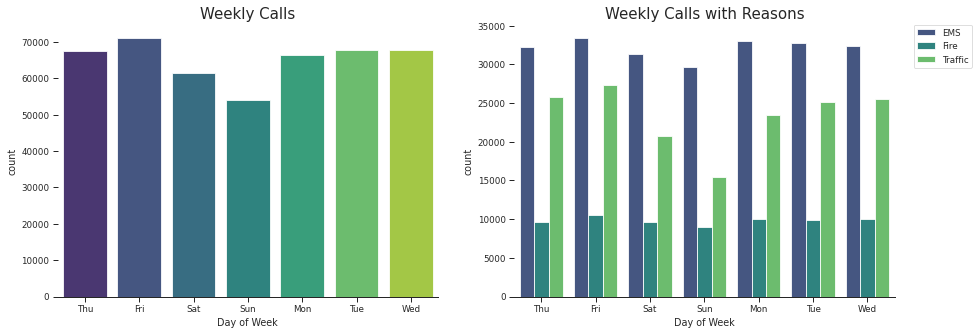

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='Day of Week',data=df,palette='viridis',ax=axes[0])
axes[0].set_title('Weekly Calls',size=15)
sns.countplot(x='Day of Week',data=df,hue='Reason',palette='viridis',ax=axes[1])
axes[1].set_title('Weekly Calls with Reasons', size=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
sns.despine(bottom=False,left=True)

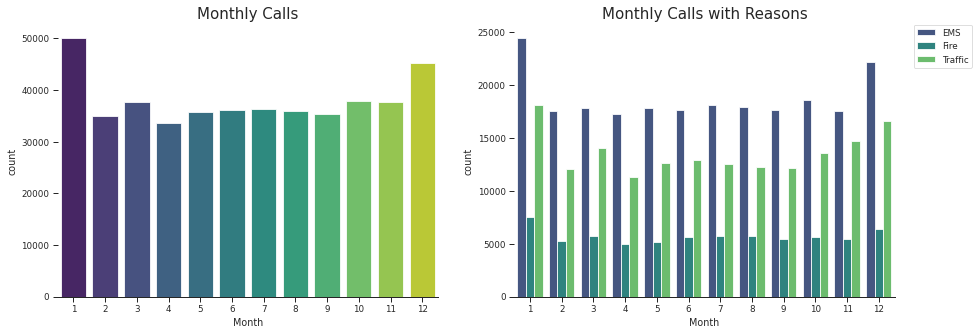

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='Month',data=df,palette='viridis',ax=axes[0])
axes[0].set_title('Monthly Calls',size=15)
sns.countplot(x='Month',data=df,hue='Reason',palette='viridis',ax=axes[1])
axes[1].set_title('Monthly Calls with Reasons', size=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
sns.despine(bottom=False,left=True)

In [ ]:
df['Date'] = df['timeStamp'].apply(lambda t: t.date())

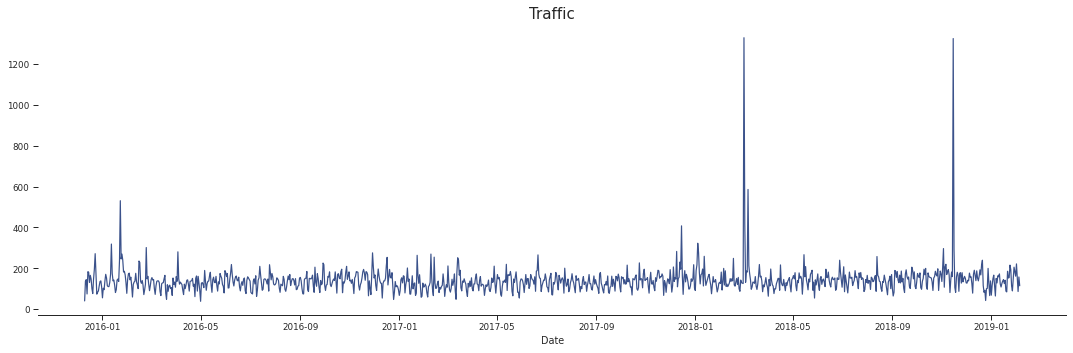

In [ ]:
df[df['Reason']=='Traffic'].groupby('Date').count()['lat'].plot(figsize=(15,5),color='#3b528b')
plt.title('Traffic',fontsize=15)
sns.despine(bottom=False,left=True)
plt.tight_layout()

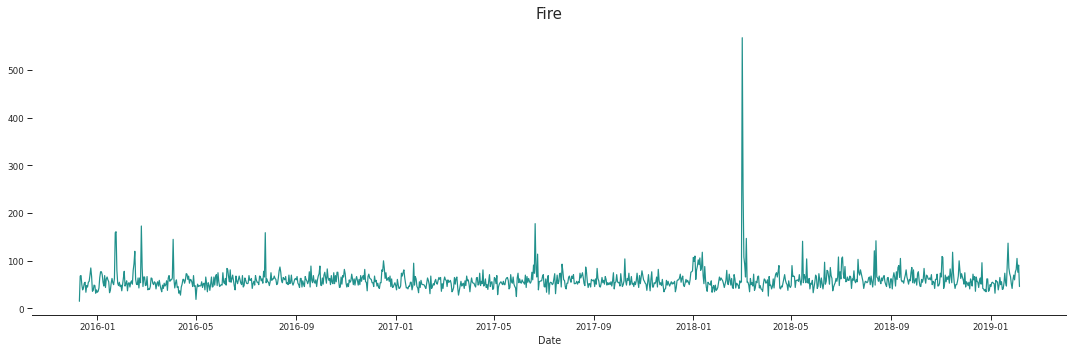

In [ ]:
df[df['Reason']=='Fire'].groupby('Date').count()['lat'].plot(figsize=(15,5),color='#21918c')
plt.title('Fire',fontsize=15)
sns.despine(bottom=False,left=True)
plt.tight_layout()

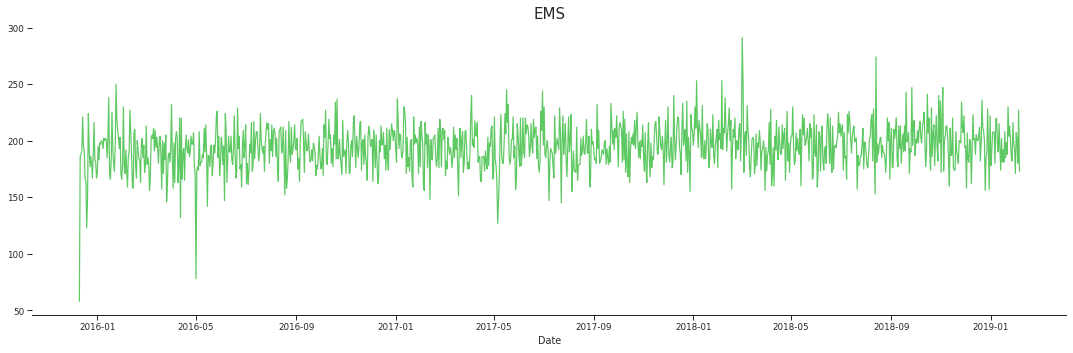

In [ ]:
df[df['Reason']=='EMS'].groupby('Date').count()['lat'].plot(figsize=(15,5), color='#5ec962')
plt.title('EMS', fontsize=15)
sns.despine(bottom=False, left=True)
plt.tight_layout()

Now let's see how we can analyze the tendency of weekly calls using heatmap

In [ ]:
# Calculating the DayHour using the timestamp
dayHour = df.groupby(by=['Day of Week', 'Hour']).count()['Reason'].unstack()

In [ ]:
dayHour

Hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,,,,
Fri,1272,1094,995,917,883,1137,1838,2914,3443,3586,3815,3999,4204,4295,4498,4875,5070,4947,3909,3495,3011,2646,2387,2005
Mon,1295,1047,946,869,943,1216,1876,3037,3886,3989,3708,3872,4074,3855,3866,4268,4405,4369,3795,3051,2606,2199,1844,1400
Sat,1635,1427,1296,1089,1011,1055,1312,1759,2404,2987,3353,3706,3828,3790,3750,3562,3597,3530,3437,3268,2840,2672,2248,2078
Sun,1660,1449,1363,1128,1041,1021,1206,1689,2089,2608,3009,2985,3311,3135,3228,3056,3091,3097,3025,2848,2545,2140,1759,1574
Thu,1189,936,979,833,836,1173,1943,3087,3720,3752,3780,3788,4051,4264,4153,4433,4309,4753,3831,3151,2741,2386,1896,1598
Tue,1189,1004,893,859,881,1174,1945,3149,3924,3821,3798,3916,3947,4001,4106,4399,4595,4775,3989,3150,2692,2292,1834,1449
Wed,1112,1012,865,871,764,1126,1900,3309,3826,3796,3716,3883,4017,3949,4175,4416,4737,4827,3845,3111,2814,2374,1927,1495


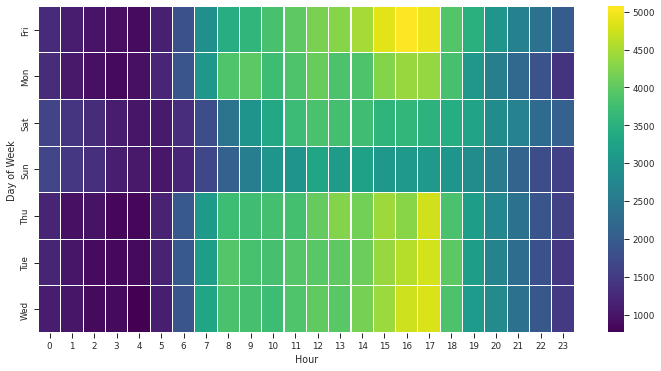

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(dayHour,cmap='viridis',linewidths=0.05)

Now let's plot a cluster map for getting much better understanding

<Figure size 864x432 with 0 Axes>

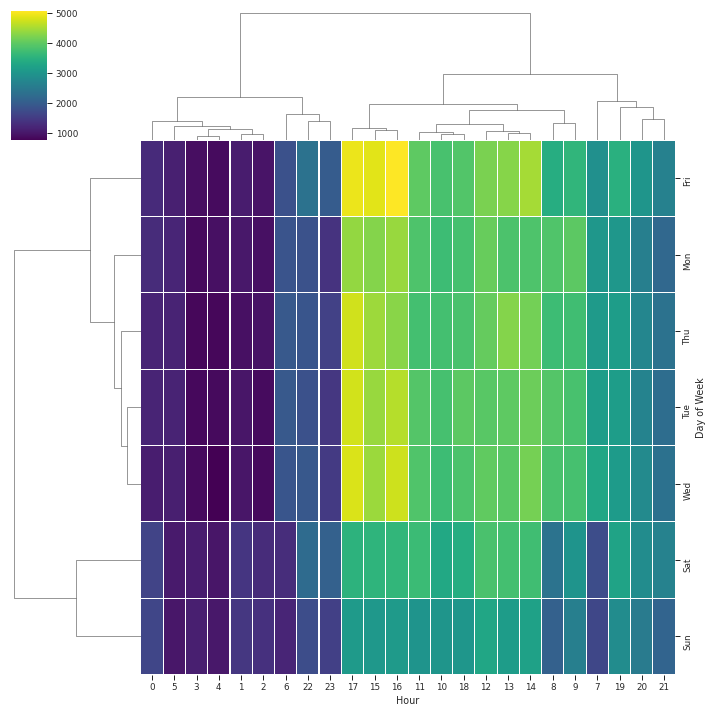

In [ ]:
plt.figure(figsize=(12,6))
sns.clustermap(dayHour,cmap='viridis',linewidths=0.05)

#### Let's plot a few points to take a look

In [ ]:
import folium as fo

#### We will consider only EMS (Emergency Medical Services) to make the clustering analysis, considering the hospitals are the ones responsible for attending this service category.

In [ ]:
#There are 3 major categories: EMS (Emergency Medical Services), Traffic and Fire, 
#so let's use them to aggregate data
df['title']=df['title'].str.split(':').str.get(0)

In [ ]:
EMS=df[df['title']=='EMS']
EMS

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,title_code,Station,Day of week,Date,Month,Year,Hour,Day/Night,Day of Week
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1.0,EMS,BACK PAINS/INJURY,Station 332,Thu,2015-12-10,12,2015,17,Day,Thu
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1.0,EMS,DIABETIC EMERGENCY,Station 345,Thu,2015-12-10,12,2015,17,Day,Thu
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1.0,EMS,CARDIAC EMERGENCY,Station 308A,Thu,2015-12-10,12,2015,16,Day,Thu
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1.0,EMS,DIZZINESS,Station 329,Thu,2015-12-10,12,2015,16,Day,Thu
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS,2015-12-10 15:39:04,LANSDALE,CANNON AVE & W 9TH ST,1.0,EMS,HEAD INJURY,Station 345,Thu,2015-12-10,12,2015,15,Day,Thu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456563,40.340072,-75.591709,SWINEHART RD & DOUGLASS ST; DOUGLASS; Station...,NaN,EMS,2019-02-05 16:40:35,DOUGLASS,SWINEHART RD & DOUGLASS ST,1.0,EMS,CARDIAC EMERGENCY,Station 332,Tue,2019-02-05,2,2019,16,Day,Tue
456566,40.306285,-75.597589,SWAMP PIKE & MIDDLE CREEK RD; NEW HANOVER; St...,19525.0,EMS,2019-02-05 16:41:06,NEW HANOVER,SWAMP PIKE & MIDDLE CREEK RD,1.0,EMS,VEHICLE ACCIDENT,Station 332,Tue,2019-02-05,2,2019,16,Day,Tue
456567,40.117382,-75.342850,SWEDE ST & W MARSHALL ST; NORRISTOWN; Station...,19401.0,EMS,2019-02-05 16:45:14,NORRISTOWN,SWEDE ST & W MARSHALL ST,1.0,EMS,ALTERED MENTAL STATUS,Station 308A,Tue,2019-02-05,2,2019,16,Day,Tue
456568,40.266079,-75.244149,RICHARDSON RD; MONTGOMERY; Station 345; 2019-...,19446.0,EMS,2019-02-05 16:43:39,MONTGOMERY,RICHARDSON RD,1.0,EMS,VEHICLE ACCIDENT,Station 345,Tue,2019-02-05,2,2019,16,Day,Tue


Text(0.5, 1.0, 'Top 25 towns with more calls')

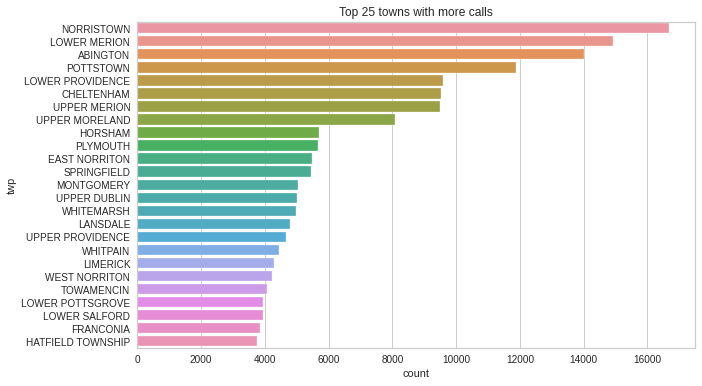

In [ ]:
#Top 25 towns with more calls
top_25=EMS['twp'].value_counts(ascending=False,normalize=True).head(25).index
plt.figure(figsize=(10,6))
sns.countplot(y='twp',data=EMS,order=top_25)
plt.title('Top 25 towns with more calls')

In [ ]:
Map=fo.Map([40.121354,-75.363829],zoom_start=7)
random_index=np.random.choice(df.index,1000) #getting some random points to plot
for ind in random_index:
    lat=df.loc[ind,'lat']
    long=df.loc[ind,'lng']
    fo.CircleMarker([lat,long],radius=2).add_to(Map)
Map

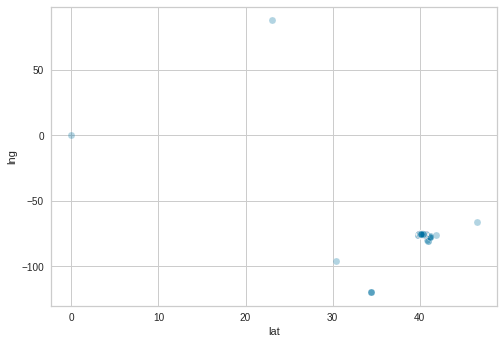

In [ ]:
sns.scatterplot(x=EMS['lat'],y=EMS['lng'],data=df, alpha=0.3)

#### Apparently there are some outliers. Let's use boxplot to do this analysis.


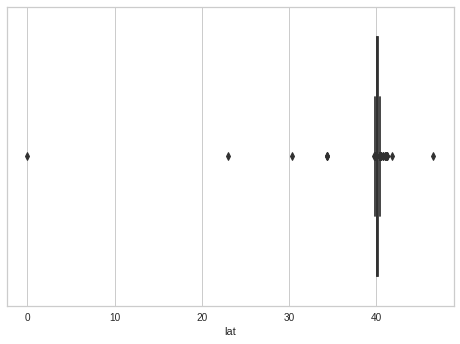

In [ ]:
#Analysing Latitude
sns.boxplot(x=EMS['lat'])

In [ ]:
#Getting outliers data
Q1=EMS['lat'].quantile(.25)
Q3=EMS['lat'].quantile(.75)
IQR=Q3-Q1
Lower_Whisker=Q1-1.5*IQR
Upper_Whisker = Q3+1.5*IQR

In [ ]:
#How many outliers?
EMS[EMS['lat']>Upper_Whisker].shape[0]+EMS[EMS['lat']<Lower_Whisker].shape[0]

185

In [ ]:
#Let's save the outliers for posteriori analysis
outliers=EMS[(EMS['lat']>Upper_Whisker)|(EMS['lat']<Lower_Whisker)]

In [ ]:
#removing outliers
EMS_treated=EMS[(EMS['lat']<Upper_Whisker)&(EMS['lat']>Lower_Whisker)]

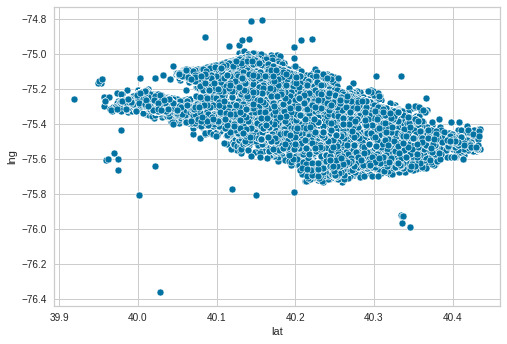

In [ ]:
#Plotting the treated data 
sns.scatterplot(x=EMS_treated['lat'],y=EMS_treated['lng'],data=df)

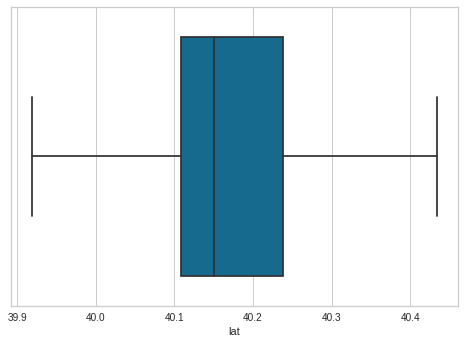

In [ ]:
#boxplot with treated data
sns.boxplot(x=EMS_treated['lat'])

#### It's possible to see a big difference already. Those who knows a bit about latitude and longitude know that a small variance in any value (lat or long) can make a big difference. Let's repeat the process for longitude.


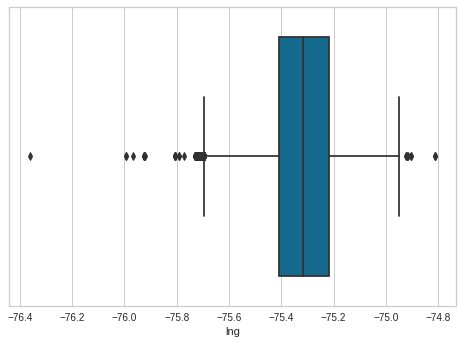

In [ ]:
#the same process for long
sns.boxplot(x=EMS_treated['lng'])

In [ ]:
Q1=EMS_treated['lng'].quantile(.25)
Q3=EMS_treated['lng'].quantile(.75)
IQR=Q3-Q1
Lower_Whisker=Q1-1.5*IQR
Upper_Whisker = Q3+1.5*IQR

In [ ]:
#How many outliers?
EMS_treated[EMS_treated['lng']>Upper_Whisker].shape[0]+EMS_treated[EMS_treated['lng']<Lower_Whisker].shape[0]

315

In [ ]:
#saving outliers
outliers=pd.concat([EMS_treated[(EMS_treated['lng']>Upper_Whisker)|(EMS_treated['lng']<Lower_Whisker)],outliers])

In [ ]:
#cleaning longitude outliers
EMS_treated=EMS_treated[(EMS_treated['lng']<Upper_Whisker)&(EMS_treated['lng']>Lower_Whisker)]

In [ ]:
#Total outliers
outliers.shape[0]

500

In [ ]:
#Percentagem in relation to the whole data
(outliers.shape[0]/EMS.shape[0])*100

0.22246446130230693

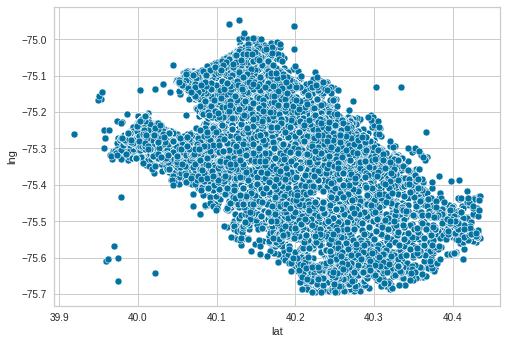

In [ ]:
#Let's see again the treated data
#It's clear the improvement of this plot in relation to the first ones
sns.scatterplot(x=EMS_treated['lat'],y=EMS_treated['lng'],data=df)

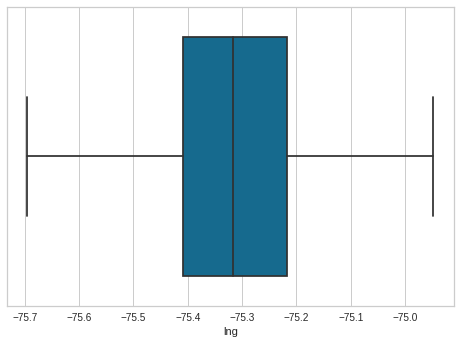

In [ ]:
sns.boxplot(x=EMS_treated['lng'])

#### Now we can plot these data in a real map to see if there is really some difference


In [ ]:
#Outliers in red
Map_outliers=fo.Map([40.269061,-75.69959],zoom_start=6)
for index,row in outliers.iterrows():
    lat=row['lat']
    long=row['lng']
    fo.CircleMarker([lat,long],radius=2,color='red').add_to(Map_outliers)

# Treated data in blue
random_indexes=np.random.choice(EMS_treated.index,2000)
for rand_in in random_indexes:
    lat=EMS_treated.loc[rand_in,'lat']
    long=EMS_treated.loc[rand_in,'lng']
    fo.CircleMarker([lat,long],radius=2,color='blue').add_to(Map_outliers)
Map_outliers

Output hidden; open in https://colab.research.google.com to view.

#### If we zoom out we can see points in other states of USA. Also there are points even in the ocean and in another continent.

#### One may say that there are points next to the aggregated data (those near to West Grove and East Greenville, for instance) and even so they were considered as outliers. Again, these data are not so representative in relation to the whole data and, in a practical way, these calls can easily be attended since they are not far from the massive data, where the facilities are to be located in order to attend the calls.


# Lets apply Clustering algorithm

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
#Getting lat long
X=np.array(EMS_treated[['lat','lng']])
X

array([[ 40.2978759, -75.5812935],
       [ 40.2580614, -75.2646799],
       [ 40.116153 , -75.343513 ],
       ...,
       [ 40.117382 , -75.34285  ],
       [ 40.2660789, -75.244149 ],
       [ 40.171699 , -75.1279885]])

In [ ]:
#creating instance of KMeans
model= KMeans(init='k-means++')

In [ ]:
#Creating instance of Elbow Visualizer to find how many clusters we use
visualizer = KElbowVisualizer(model, k=(5,20))

AttributeError: ignored

TypeError: ignored

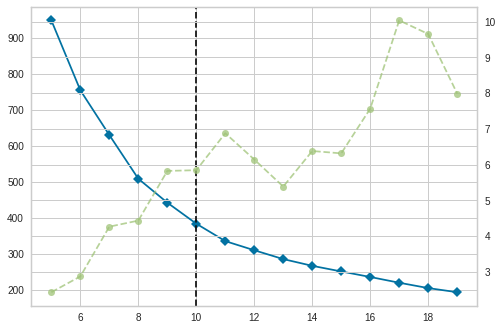

In [ ]:
#Fitting the model
visualizer.fit(X)

#### We will use k=10 according to the Visualizer.


In [ ]:
clustering=KMeans(init='k-means++',n_clusters=10)
clustering.fit(X)    

KMeans(n_clusters=10)

In [ ]:
clusters=clustering.cluster_centers_

In [ ]:
Map=fo.Map([ 40.13572425, -75.20909773],zoom_start=8)
random_indexes=np.random.choice(EMS_treated.index,2000)
for rand_in in random_indexes:
    lat=EMS_treated.loc[rand_in,'lat']
    long=EMS_treated.loc[rand_in,'lng']
    fo.CircleMarker([lat,long],radius=2,color='blue').add_to(Map)    
    
for c in clusters:
    lat=c[0]
    lng=c[1]
    fo.RegularPolygonMarker([lat,lng],radius=4,number_of_sides=3,color='black').add_to(Map) 

Map

#### A clusterization can gives us an ideia of how to alocate our facilities in order to attend the anual emergency calls. Of course in a real case we cannot rely our answer only in a clustering result, but this is a good "first kick" to start our analysis, since KMeans clustering is based on data distribution